# RSSI Analyzer — Model 2: RSU-tier XGBoost (Centralised)
Builds aggregate features over **5 s / 2 s sliding windows per claimed identity**.
Binary classifier: Legitimate (0) vs Sybil (1).
Suspicion score: **p̄_RSSI = 1 − P(class=0)** (Eq 3.X).
Outputs: `pbar_rssi_windows.csv`, `pbar_rssi_per_identity.csv`, `rssi_xgb_model.pkl`

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedShuffleSplit, ShuffleSplit, cross_val_score, StratifiedKFold
from sklearn.metrics import (matthews_corrcoef, confusion_matrix,
                              classification_report, accuracy_score, f1_score)
from xgboost import XGBClassifier
import joblib

DATASET_PATH = '/home/nsuser/FYP/ns3-sdven-sybil-detector/sybil-attack/outputs/rssi_verification_log_Dataset.csv'
OUTPUT_DIR   = '/home/nsuser/FYP/ns3-sdven-sybil-detector/sybil-attack/outputs/rssi_model2_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

XGB_HP = dict(
    n_estimators     = 300,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 2.0,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)
WINDOW_SEC = 5.0
STEP_SEC   = 2.0
SEED       = 42
print(f'XGBoost HP: {XGB_HP}')

XGBoost HP: {'n_estimators': 300, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


## Step 1 — Load & Label Data

In [2]:
print(f'Loading {DATASET_PATH} ...')
df_raw = pd.read_csv(DATASET_PATH)
before = len(df_raw)
df_raw = df_raw.drop_duplicates(
    subset=['time', 'observer_vehicle_id', 'observed_claimed_id',
            'observed_real_id', 'rssi_dbm'])
removed = before - len(df_raw)
print(f'Rows after dedup: {len(df_raw):,}  (removed {removed:,}, {removed/before:.1%})')

df_raw['is_sybil'] = (df_raw['observed_claimed_id'] != df_raw['observed_real_id']).astype(int)
print(f'Legitimate: {(df_raw.is_sybil==0).sum():,}   Sybil: {df_raw.is_sybil.sum():,}')
df_raw = df_raw.sort_values(['observed_claimed_id', 'time']).reset_index(drop=True)
df_raw.head(3)

Loading /home/nsuser/FYP/ns3-sdven-sybil-detector/sybil-attack/outputs/rssi_verification_log_Dataset.csv ...
Rows after dedup: 1,948,366  (removed 6,703,790, 77.5%)
Legitimate: 1,342,282   Sybil: 606,084


,time,observer_vehicle_id,observed_claimed_id,observed_real_id,rssi_dbm,rssi_estimated_distance_m,claimed_distance_m,mismatch_m,threshold_m,verification_state,suspicion_flags,is_sybil
0,30.0106,126,0,0,-63.8443,23.0612,30.0001,6.93889,25,VERIFIED,0,0
1,30.0106,107,0,0,-66.3561,27.3690,35.6028,8.23383,25,VERIFIED,0,0
2,30.0106,7,0,0,-69.9289,34.9180,45.4091,10.49110,25,VERIFIED,0,0


## Step 2 — RSU Feature Engineering (5 s / 2 s Windows per Claimed Identity)

In [3]:
def build_rsu_features(df, window_sec=5.0, step_sec=2.0):
    '''
    For each claimed identity, slide a window of window_sec with step_sec overlap.
    Features (Model 2 design doc):
      rssi_mean         — RSSI mean over window
      path_loss_residual — mean(estimated_dist − claimed_dist)
      pos_mismatch_mean — mean claimed-to-triangulated mismatch (m)
      dist_ratio_std    — std of (estimated_dist / claimed_dist) across observers
      observer_count    — number of distinct observers in window

    rssi_var was dropped: AUC ~0.50 (no separating power) and correlated 0.61
    with rssi_mean, so it was pure noise/redundancy.
    '''
    records = []
    for claimed_id, grp in df.groupby('observed_claimed_id'):
        grp    = grp.sort_values('time').reset_index(drop=True)
        t_arr  = grp['time'].values
        label  = int(grp['is_sybil'].iloc[0])
        real_id= grp['observed_real_id'].iloc[0]
        t = t_arr.min()
        while t < t_arr.max():
            mask = (t_arr >= t) & (t_arr < t + window_sec)
            w = grp[mask]
            if len(w) < 2:
                t += step_sec; continue
            rssi  = w['rssi_dbm'].values
            d_est = w['rssi_estimated_distance_m'].values
            d_cl  = np.maximum(w['claimed_distance_m'].values, 1.0)  # floor: avoid ratio blow-up as claimed_distance -> 0
            mis   = w['mismatch_m'].values
            records.append({
                'claimed_id'         : claimed_id,
                'real_id'            : real_id,
                'window_start'       : round(float(t), 3),
                'rssi_mean'          : float(rssi.mean()),
                'path_loss_residual' : float((d_est - d_cl).mean()),
                'pos_mismatch_mean'  : float(mis.mean()),
                'dist_ratio_std'     : float((d_est / d_cl).std()),
                'observer_count'     : int(w['observer_vehicle_id'].nunique()),
                'is_sybil'           : label,
            })
            t += step_sec
    return pd.DataFrame(records)

print(f'Building RSU windows ({WINDOW_SEC}s / {STEP_SEC}s step) ...')
feat_df = build_rsu_features(df_raw, WINDOW_SEC, STEP_SEC)
n_s = feat_df['is_sybil'].sum(); n_l = len(feat_df) - n_s
print(f'Feature windows: {len(feat_df):,}   Legitimate: {n_l:,}   Sybil: {n_s:,}')
feat_df.describe().round(3)

Building RSU windows (5.0s / 2.0s step) ...
Feature windows: 12,743   Legitimate: 8,662   Sybil: 4,081


,claimed_id,real_id,window_start,rssi_mean,path_loss_residual,pos_mismatch_mean,dist_ratio_std,observer_count,is_sybil
count,1.274300e+04,12743.000,12743.000,12743.000,12743.000,12743.000,12743.000,12743.000,12743.000
mean,3.926300e+05,100.316,51.480,-67.691,-13.888,14.602,0.100,7.671,0.320
std,2.246439e+06,58.291,27.111,11.598,7.288,7.407,0.308,7.880,0.467
min,0.000000e+00,0.000,1.053,-81.979,-71.878,0.034,0.000,1.000,0.000
25%,7.300000e+01,50.000,28.503,-73.945,-16.659,10.014,0.003,3.000,0.000
50%,1.470000e+02,100.000,50.112,-69.612,-13.003,13.281,0.008,6.000,0.000
75%,6.430000e+02,151.000,73.654,-64.443,-9.645,17.177,0.076,10.000,1.000
max,1.970051e+07,199.000,102.467,40.000,26.497,71.878,9.071,109.000,1.000


## Step 3 — 70 / 15 / 15 Split (stratified by claimed identity)

In [4]:
FEATURES = ['rssi_mean', 'path_loss_residual',
            'pos_mismatch_mean', 'dist_ratio_std', 'observer_count']

# mismatch_m/threshold_m/verification_state/suspicion_flags are rule-derived from
# the same claimed-vs-estimated distance comparison used to label is_sybil-adjacent
# behaviour — they must never be fed to the model as features.
LEAKY_COLUMNS = {'mismatch_m', 'threshold_m', 'verification_state', 'suspicion_flags',
                  'is_sybil', 'real_id', 'claimed_id'}
assert not (set(FEATURES) & LEAKY_COLUMNS), 'leakage: a rule-derived/label column is in FEATURES'

unique_ids = feat_df['claimed_id'].unique()
id_labels  = feat_df.groupby('claimed_id')['is_sybil'].first().loc[unique_ids].values

sss1 = StratifiedShuffleSplit(1, test_size=0.30, random_state=SEED)
tr_i, vt_i = next(sss1.split(unique_ids, id_labels))
vt_lbl = id_labels[vt_i]
if np.bincount(vt_lbl).min() >= 2:
    sss2 = StratifiedShuffleSplit(1, test_size=0.50, random_state=SEED)
    va_i, te_i = next(sss2.split(unique_ids[vt_i], vt_lbl))
else:
    ss2 = ShuffleSplit(1, test_size=0.50, random_state=SEED)
    va_i, te_i = next(ss2.split(unique_ids[vt_i]))

train_ids = set(unique_ids[tr_i])
val_ids   = set(unique_ids[vt_i][va_i])
test_ids  = set(unique_ids[vt_i][te_i])

train_df = feat_df[feat_df['claimed_id'].isin(train_ids)].reset_index(drop=True)
val_df   = feat_df[feat_df['claimed_id'].isin(val_ids  )].reset_index(drop=True)
test_df  = feat_df[feat_df['claimed_id'].isin(test_ids )].reset_index(drop=True)

X_train = train_df[FEATURES]; y_train = train_df['is_sybil']
X_val   = val_df[FEATURES];   y_val   = val_df['is_sybil']
X_test  = test_df[FEATURES];  y_test  = test_df['is_sybil']
print(f'Train: {len(X_train):,}   Val: {len(X_val):,}   Test: {len(X_test):,}')
print(f'Features ({len(FEATURES)}): {FEATURES}')

Train: 8,770   Val: 2,027   Test: 1,946
Features (5): ['rssi_mean', 'path_loss_residual', 'pos_mismatch_mean', 'dist_ratio_std', 'observer_count']


## Step 4 — Train XGBoost: Grid Search max_depth ∈ {5, 6, 7}, Early Stopping on Val MCC

In [5]:
best_depth, best_val_mcc, model_xgb = 6, -1.0, None

for depth in [5, 6, 7]:
    m = XGBClassifier(
        objective='binary:logistic',
        max_depth=depth,
        early_stopping_rounds=30,
        **XGB_HP,
    )
    m.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)
    vmcc = matthews_corrcoef(y_val, m.predict(X_val))
    ntrees = m.best_iteration + 1 if hasattr(m, 'best_iteration') else XGB_HP['n_estimators']
    print(f'  max_depth={depth}  val MCC={vmcc:.4f}  trees used={ntrees}')
    if vmcc > best_val_mcc:
        best_val_mcc, best_depth, model_xgb = vmcc, depth, m

print(f'\nBest max_depth={best_depth}   val MCC={best_val_mcc:.4f}')

  max_depth=5  val MCC=0.9269  trees used=299
  max_depth=6  val MCC=0.9373  trees used=299
  max_depth=7  val MCC=0.9384  trees used=300

Best max_depth=7   val MCC=0.9384


In [10]:
y_pred   = model_xgb.predict(X_test)
y_proba  = model_xgb.predict_proba(X_test)
test_mcc = matthews_corrcoef(y_test, y_pred)
acc      = accuracy_score(y_test, y_pred)
f1_m     = f1_score(y_test, y_pred, average='macro')
cm2      = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm2.ravel()

print(f'Test MCC : {test_mcc:.4f}')
print(f'Accuracy : {acc:.4f}   F1 Macro: {f1_m:.4f}')
print(f'Sybil Recall: {tp/(tp+fn):.4f}   False Alarm: {fp/(fp+tn):.4f}')
print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Sybil'], zero_division=0))

Test MCC : 0.9539
Accuracy : 0.9800   F1 Macro: 0.9769
Sybil Recall: 0.9616   False Alarm: 0.0114
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.99      1321
       Sybil       0.98      0.96      0.97       625

    accuracy                           0.98      1946
   macro avg       0.98      0.98      0.98      1946
weighted avg       0.98      0.98      0.98      1946



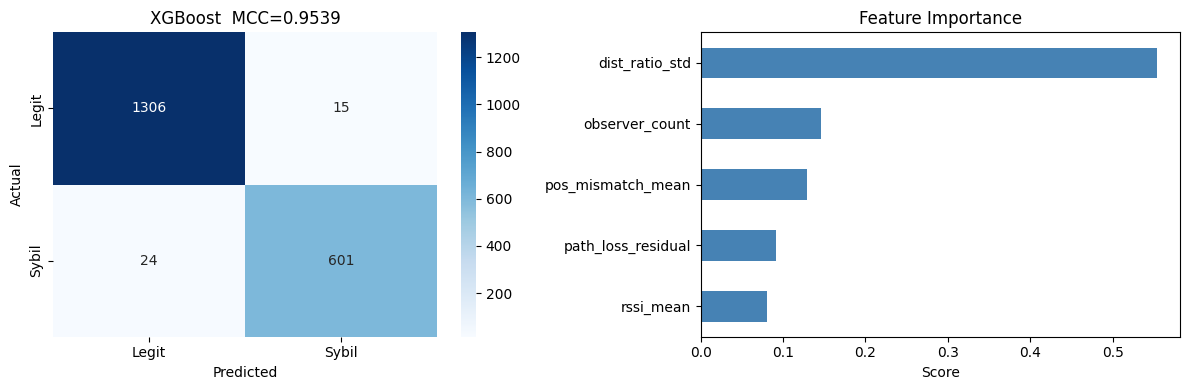

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Sybil'],
            yticklabels=['Legit', 'Sybil'], ax=ax1)
ax1.set(xlabel='Predicted', ylabel='Actual', title=f'XGBoost  MCC={test_mcc:.4f}')

imp = pd.Series(model_xgb.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind='barh', ax=ax2, color='steelblue')
ax2.set(title='Feature Importance', xlabel='Score')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/xgb_results.png', dpi=150)
plt.show()

## Step 5 — Export p̄_RSSI Suspicion Scores (all data)

In [8]:
# p_bar_RSSI(v_i) = 1 − P(class=0 | v_i)
X_all     = feat_df[FEATURES]
proba_all = model_xgb.predict_proba(X_all)   # (N, 2): col0=P(legit), col1=P(sybil)

feat_df['p_bar_rssi'] = (1.0 - proba_all[:, 0]).astype(np.float32)

# Window-level table
pbar_wins = feat_df[['claimed_id', 'real_id', 'window_start', 'p_bar_rssi', 'is_sybil']]
pbar_wins.to_csv(f'{OUTPUT_DIR}/pbar_rssi_windows.csv', index=False)
print(f'Window-level p_bar_RSSI: {len(pbar_wins):,} rows -> pbar_rssi_windows.csv')

# Per-identity mean (used in Ensemble notebook)
id_pbar = feat_df.groupby('claimed_id').agg(
    real_id=('real_id', 'first'),
    p_bar_rssi=('p_bar_rssi', 'mean'),
    is_sybil=('is_sybil', 'first'),
).reset_index()
id_pbar.to_csv(f'{OUTPUT_DIR}/pbar_rssi_per_identity.csv', index=False)
print(f'Per-identity p_bar_RSSI: {len(id_pbar)} rows -> pbar_rssi_per_identity.csv')
id_pbar.head()

Window-level p_bar_RSSI: 12,743 rows -> pbar_rssi_windows.csv
Per-identity p_bar_RSSI: 1002 rows -> pbar_rssi_per_identity.csv


,claimed_id,real_id,p_bar_rssi,is_sybil
0,0,0,0.003997,0
1,1,1,0.038099,0
2,2,2,0.009433,0
3,3,3,0.002024,0
4,4,4,0.019893,0


## Step 6 — Save Model & Results

In [9]:
joblib.dump(model_xgb, f'{OUTPUT_DIR}/rssi_xgb_model.pkl')
joblib.dump(FEATURES,   f'{OUTPUT_DIR}/rssi_xgb_features.pkl')

results2 = {
    'model'        : 'XGBoost_RSU_Binary',
    'best_depth'   : int(best_depth),
    'test_mcc'     : round(float(test_mcc), 6),
    'val_mcc'      : round(float(best_val_mcc), 6),
    'accuracy'     : round(float(acc), 6),
    'f1_macro'     : round(float(f1_m), 6),
    'sybil_recall' : round(float(tp / (tp + fn)), 6),
    'false_alarm'  : round(float(fp / (fp + tn)), 6),
    'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
    'features'     : FEATURES,
    'window_sec'   : WINDOW_SEC,
    'step_sec'     : STEP_SEC,
}
with open(f'{OUTPUT_DIR}/xgb_results.json', 'w') as f:
    json.dump(results2, f, indent=2)

print('=== OUTPUTS ===')
for fn_ in ['rssi_xgb_model.pkl', 'rssi_xgb_features.pkl', 'xgb_results.json',
            'pbar_rssi_windows.csv', 'pbar_rssi_per_identity.csv', 'xgb_results.png']:
    p = f'{OUTPUT_DIR}/{fn_}'
    print(f'  [{"OK" if os.path.exists(p) else "MISSING"}]  {fn_}')
print(f'\nTest MCC: {test_mcc:.4f}')

=== OUTPUTS ===
  [OK]  rssi_xgb_model.pkl
  [OK]  rssi_xgb_features.pkl
  [OK]  xgb_results.json
  [OK]  pbar_rssi_windows.csv
  [OK]  pbar_rssi_per_identity.csv
  [OK]  xgb_results.png

Test MCC: 0.9539
